In [2]:
import os
import pandas as pd
import boto3
import pickle
import matplotlib.pyplot as plt
import plotly.express as px
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
import os
import pickle
import boto3
from dotenv import load_dotenv

# Cargar variables de entorno
load_dotenv()

# Configurar cliente de S3
s3_client = boto3.client(
    's3',
    aws_access_key_id=os.getenv('NOTEBOOK_ACCESS_KEY'),
    aws_secret_access_key=os.getenv('NOTEBOOK_ACCESS_KEY_SECRET')
)

bucket_name = 'chicago-inspections-analytics'
ingesta_inicial_key = 'ingesta/inicial/inspecciones-historicas-2024-11-12T19-51-57.pkl'
ingesta_consecutivas_folder = 'ingesta/consecutiva/'

# Variable para llevar el total de los datos descargados
total_bytes_descargados = 0

# Función para cargar un archivo desde S3 y convertirlo en DataFrame
def cargar_ingesta_s3(s3_client, bucket, key):
    global total_bytes_descargados
    file_obj = s3_client.get_object(Bucket=bucket, Key=key)
    file_data = file_obj['Body'].read()
    total_bytes_descargados += len(file_data)  # Acumulando el tamaño del archivo descargado
    return pickle.loads(file_data)

# Cargar ingesta inicial
df_total = cargar_ingesta_s3(s3_client, bucket_name, ingesta_inicial_key)
print("✅ Ingesta inicial cargada exitosamente.")

# Listar los archivos en la carpeta de ingestas consecutivas
response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=ingesta_consecutivas_folder)

# Verificar si hay archivos en la carpeta
if 'Contents' in response:
    for obj in response['Contents']:
        file_key = obj['Key']
        
        # Saltar si el archivo es un folder
        if file_key.endswith('/'):
            continue
        
        print(f"📥 Cargando ingesta consecutiva: {file_key}")
        
        # Cargar el nuevo DataFrame e ir concatenando
        df_nueva = cargar_ingesta_s3(s3_client, bucket_name, file_key)
        df_total = pd.concat([df_total, df_nueva], ignore_index=True)

    print("✅ Todas las ingestas consecutivas han sido cargadas y concatenadas.")
else:
    print("⚠️ No se encontraron ingestas consecutivas en la carpeta.")

# Mostrar tamaño final del DataFrame y el total de datos descargados
print(f"📊 Total de registros después de concatenar: {df_total.shape[0]}")
print(f"📦 Total de datos descargados: {total_bytes_descargados / (1024**2):.2f} MB")  # Convertir a MB

✅ Ingesta inicial cargada exitosamente.
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-53-54.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-54-55.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-55-57.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-56-59.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-58-01.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-59-03.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T20-00-05.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T20-01-07.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T20-02-09.pkl
📥 Cargando ingesta consecutiva: ingesta/co

In [4]:
df_total = df_total.dropna(subset=['violations'])


In [5]:
# Función para procesar una fila de la columna 'violations'
def procesar_violations(violations_text):
    if not isinstance(violations_text, str):  # Verifica que sea texto válido
        return []  # Retorna vacío si no es string

    violations = violations_text.split("|")  # Dividir violaciones por el delimitador
    structured_data = []

    for violation in violations:
        # Extraer cada componente usando expresiones regulares
        codigo_match = re.match(r"^\d+", violation.strip())  # Número de código al inicio
        categoria_match = re.search(r"^\d+\.\s(.+?)\s- Comments:", violation)  # Categoría
        comentarios_match = re.search(r"- Comments:(.+?)\(", violation)  # Comentarios antes del primer paréntesis
        metadatos_match = re.findall(r"\(([^)]+)\)", violation)  # Todo lo que está entre paréntesis

        # Agregar datos estructurados
        structured_data.append({
            "Código": codigo_match.group() if codigo_match else None,
            "Categoría": categoria_match.group(1).strip() if categoria_match else None,
            "Comentarios": comentarios_match.group(1).strip() if comentarios_match else None,
            "Metadatos": "; ".join(metadatos_match) if metadatos_match else None
        })

    return structured_data

# Iterar sobre cada fila y procesar
resultado = []
for _, row in df_total.iterrows():
    # Procesar la columna 'violations'
    registros = procesar_violations(row.get('violations', ''))  # Maneja valores no válidos
    # Agregar inspection_id para la relación 1 a muchos
    for registro in registros:
        registro["inspection_id"] = row['inspection_id']  # Vincular con el identificador único
        registro["results"] = row['results']  # Agregar el valor de 'results' a cada registro
        resultado.append(registro)

# Convertir los resultados en un DataFrame estructurado
df_procesado = pd.DataFrame(resultado)


In [6]:
valores_a_eliminar = ['Out of Business', 'No Entry', 'Not Ready']
df_procesado = df_procesado[~df_procesado['results'].isin(valores_a_eliminar)]

# 2️⃣ Eliminar cualquier fila con valores NaN en la columna 'results'
df_procesado = df_procesado.dropna(subset=['results'])

# 3️⃣ Reemplazar 'Pass w/ Conditions' por 'Pass'
df_procesado['results'] = df_procesado['results'].replace('Pass w/ Conditions', 'Pass')


In [7]:
df_procesado=df_procesado.dropna()
df_procesado.head()

,Código,Categoría,Comentarios,Metadatos,inspection_id,results
24,3,POTENTIALLY HAZARDOUS FOOD MEETS TEMPERATURE R...,All cold food shall be stored at a temperature...,"FOOD WAS COOKED ON 1-4-10, PER COOK COMMMENT; A",67759,Pass
226,35,"WALLS, CEILINGS, ATTACHED EQUIPMENT CONSTRUCTE...",REPLACE WATER DAMAGED TILES,CEILING,98313,Fail
267,16,"FOOD PROTECTED DURING STORAGE, PREPARATION, DI...",All food should be properly protected from con...,uncovered,74261,Fail
277,18,NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS...,All necessary control measures shall be used t...,PESTICIDES,74259,Fail
321,18,NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS...,NUMEROUS,OVER 10,67768,Fail


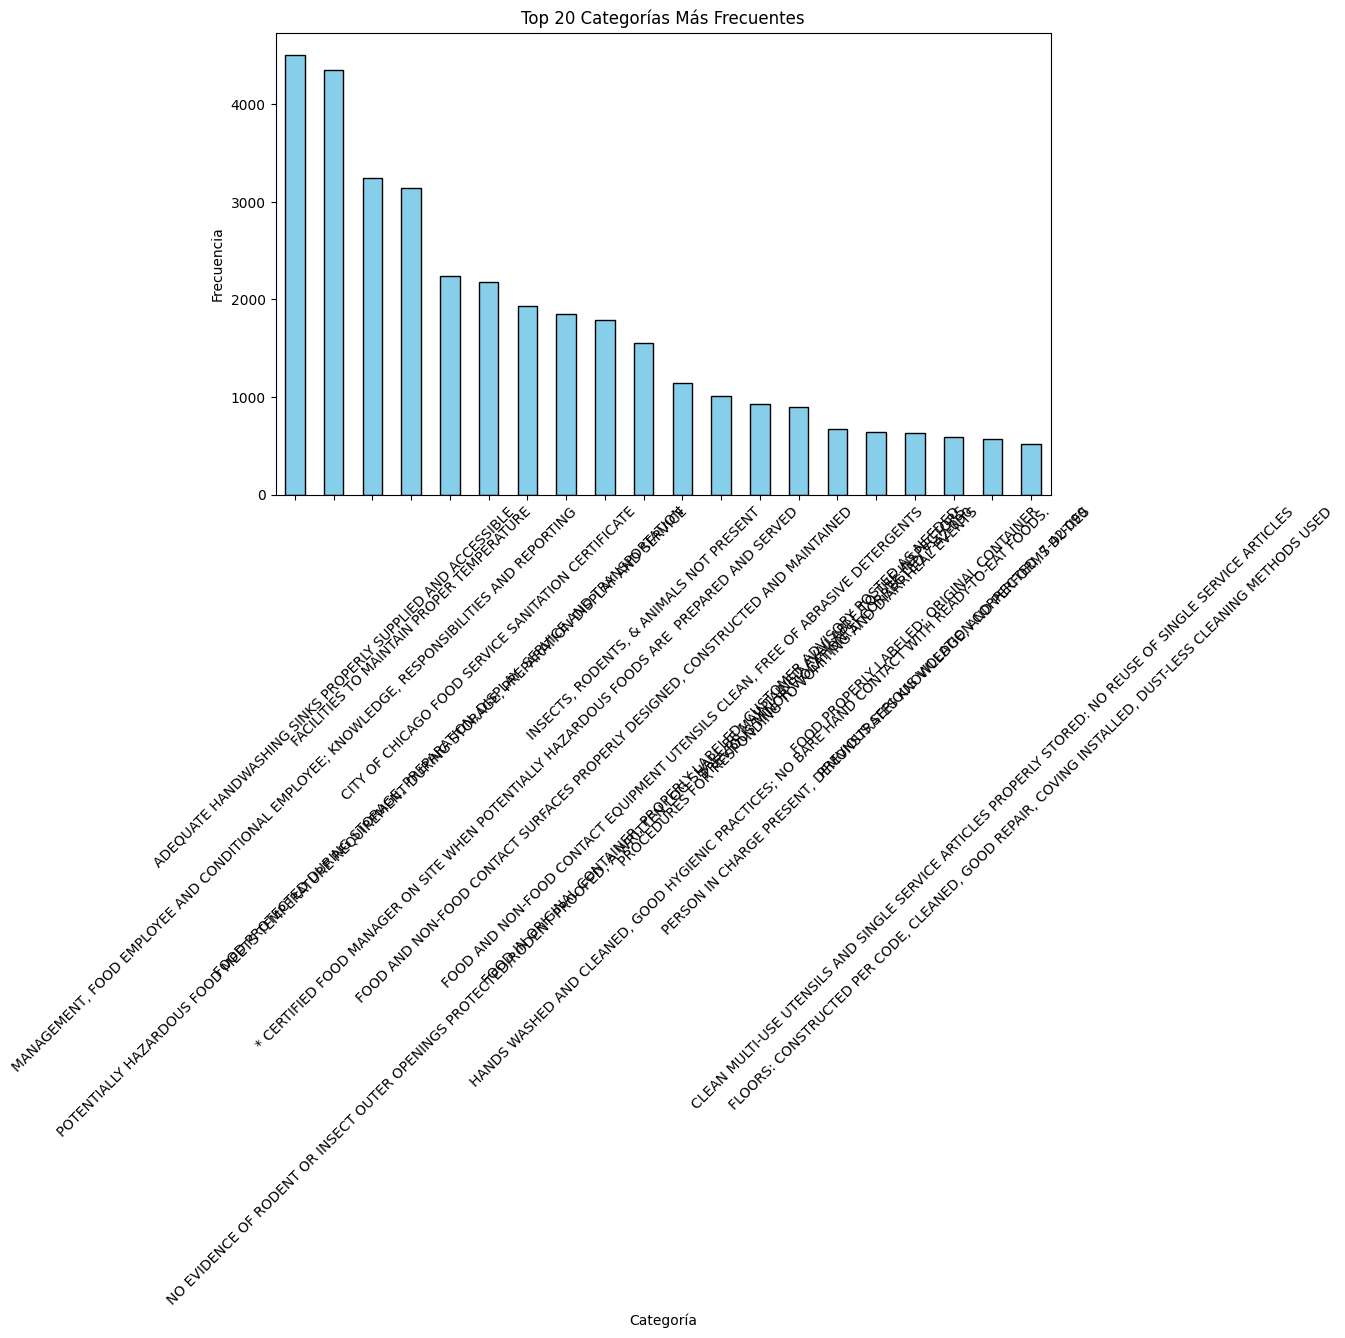

In [8]:
# Contar las frecuencias de cada categoría
categoria_counts = df_procesado['Categoría'].value_counts()


# Tomar las primeras 20 categorías más frecuentes
top_20_categorias = categoria_counts.head(20)

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
top_20_categorias.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 20 Categorías Más Frecuentes')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

fusionar comentarios y categorias

In [9]:
# Fusionar las columnas 'Categoría' y 'Comentarios' en la columna 'Comentarios'
df_procesado['Comentarios'] = df_procesado['Categoría'].astype(str) + " " + df_procesado['Comentarios']

# Eliminar la columna 'Categoría' (si ya no es necesaria)
df_procesado = df_procesado.drop('Categoría', axis=1)


In [10]:
df_procesado.head()

,Código,Comentarios,Metadatos,inspection_id,results
24,3,POTENTIALLY HAZARDOUS FOOD MEETS TEMPERATURE R...,"FOOD WAS COOKED ON 1-4-10, PER COOK COMMMENT; A",67759,Pass
226,35,"WALLS, CEILINGS, ATTACHED EQUIPMENT CONSTRUCTE...",CEILING,98313,Fail
267,16,"FOOD PROTECTED DURING STORAGE, PREPARATION, DI...",uncovered,74261,Fail
277,18,NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS...,PESTICIDES,74259,Fail
321,18,NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS...,OVER 10,67768,Fail


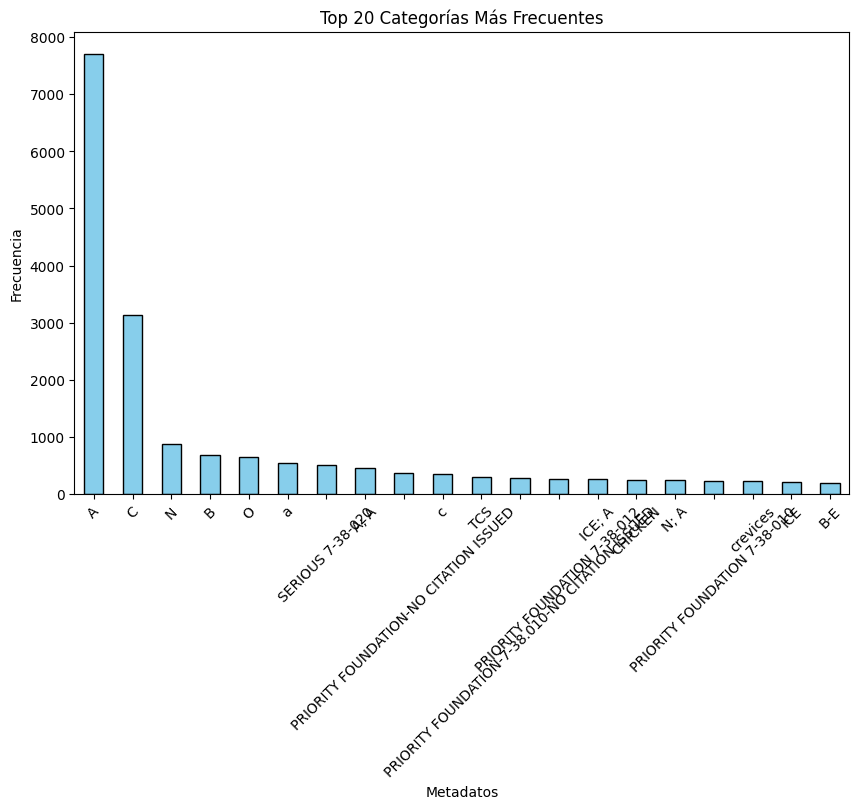

In [11]:
metadatos_counts = df_procesado['Metadatos'].value_counts()


# Tomar las primeras 20 categorías más frecuentes
top_20_categorias = metadatos_counts.head(20)

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
top_20_categorias.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 20 Categorías Más Frecuentes')
plt.xlabel('Metadatos')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

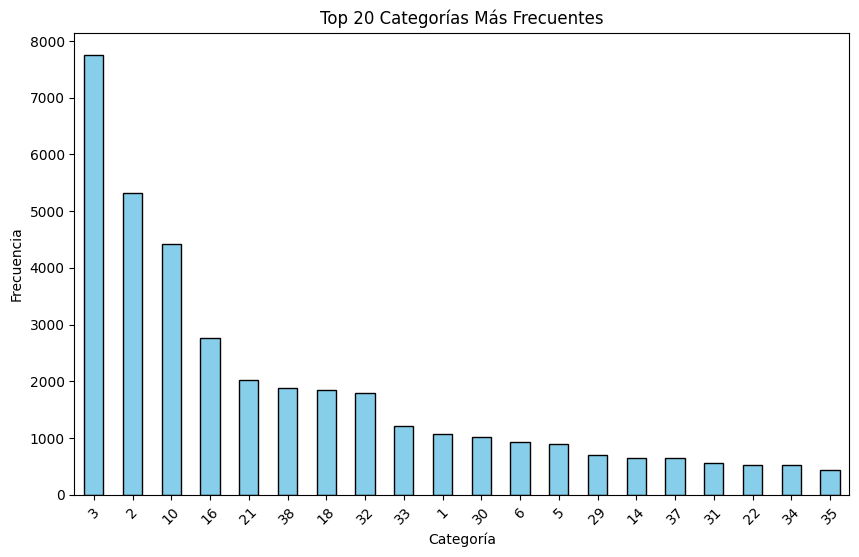

In [12]:
# Contar las frecuencias de cada categoría
codigo_counts = df_procesado['Código'].value_counts()


# Tomar las primeras 20 categorías más frecuentes
top_20_categorias = codigo_counts.head(20)

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
top_20_categorias.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 20 Categorías Más Frecuentes')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [13]:
!pip install transformers
!pip install torch


In [14]:
import torch
from transformers import BertTokenizer, BertModel

print(torch.__version__)
print(BertTokenizer.from_pretrained('bert-base-uncased'))


/home/antonio/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.6.0+cu124
BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [15]:
pip show torch


Name: torch
Version: 2.6.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /home/antonio/miniconda3/lib/python3.12/site-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [16]:
pip show transformers


Name: transformers
Version: 4.49.0
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /home/antonio/miniconda3/lib/python3.12/site-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: 
Note: you may need to restart the kernel to use updated packages.


embebings para comentarios

In [17]:
torch.cuda.is_available()


True

In [18]:
import torch
from tqdm import tqdm
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertModel

# Configuración de dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar el modelo y tokenizer BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').to(device)

# Función para obtener los embeddings de los comentarios
def get_bert_embeddings(texts, batch_size=8):
    embeddings = []
    # Procesamos los textos en lotes
    for i in tqdm(range(0, len(texts), batch_size), desc="Procesando comentarios", unit="lote"):
        batch_texts = texts[i:i + batch_size]
        
        # Tokenizar el lote de textos
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
        inputs = {key: value.to(device) for key, value in inputs.items()}
        
        # Obtener embeddings sin gradientes
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Promediar los embeddings a lo largo de la secuencia (dim=1) y mover a la CPU
        batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.append(batch_embeddings)
        
        # Limpiar la caché de la GPU
        torch.cuda.empty_cache()
    
    # Concatenar todos los embeddings
    return np.concatenate(embeddings, axis=0)

# Simulación de DataFrame con los comentarios (sustituye con tu DataFrame real)
# df_procesado = pd.DataFrame({'Comentarios': ['Comentario 1', 'Comentario 2', 'Comentario 3', ...]})
comentarios = df_procesado['Comentarios'].tolist()

# Obtener los embeddings para los comentarios
comentarios_embeddings = get_bert_embeddings(comentarios, batch_size=8)

# Crear un DataFrame con los embeddings y los comentarios
df_embeddings = pd.DataFrame(comentarios_embeddings)

# Agregar los embeddings al DataFrame original (si lo deseas)
df_procesado['Embeddings'] = df_embeddings.values.tolist()

# Mostrar el DataFrame con los embeddings
print(df_procesado.head())



Procesando comentarios: 100%|██████████| 5298/5298 [02:48<00:00, 31.47lote/s]


    Código                                        Comentarios  \
24       3  POTENTIALLY HAZARDOUS FOOD MEETS TEMPERATURE R...   
226     35  WALLS, CEILINGS, ATTACHED EQUIPMENT CONSTRUCTE...   
267     16  FOOD PROTECTED DURING STORAGE, PREPARATION, DI...   
277     18  NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS...   
321     18  NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS...   

                                           Metadatos inspection_id results  \
24   FOOD WAS COOKED ON 1-4-10, PER COOK COMMMENT; A         67759    Pass   
226                                          CEILING         98313    Fail   
267                                        uncovered         74261    Fail   
277                                       PESTICIDES         74259    Fail   
321                                          OVER 10         67768    Fail   

                                            Embeddings  
24   [-0.2278391718864441, 0.203445702791214, 0.087...  
226  [0.24025189876556396,

In [19]:
df_procesado.head()

,Código,Comentarios,Metadatos,inspection_id,results,Embeddings
24,3,POTENTIALLY HAZARDOUS FOOD MEETS TEMPERATURE R...,"FOOD WAS COOKED ON 1-4-10, PER COOK COMMMENT; A",67759,Pass,"[-0.2278391718864441, 0.203445702791214, 0.087..."
226,35,"WALLS, CEILINGS, ATTACHED EQUIPMENT CONSTRUCTE...",CEILING,98313,Fail,"[0.24025189876556396, 0.12877778708934784, 0.3..."
267,16,"FOOD PROTECTED DURING STORAGE, PREPARATION, DI...",uncovered,74261,Fail,"[0.033475518226623535, 0.1958978921175003, -0...."
277,18,NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS...,PESTICIDES,74259,Fail,"[-0.06295626610517502, 0.36404797434806824, 0...."
321,18,NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS...,OVER 10,67768,Fail,"[0.1330084502696991, 0.08436712622642517, 0.16..."


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import json

# Suponiendo que 'df_procesado' ya tiene la columna 'Embeddings' con los embeddings y 'results' como la variable objetivo

# Convertir los embeddings de la columna 'Embeddings' a un formato adecuado (listas a vectores)
X = df_procesado['Embeddings'].apply(lambda x: x if isinstance(x, list) else []).apply(pd.Series)

# Codificar la variable objetivo 'results'
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_procesado['results'])

# Dividir los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ajustar pesos de clases para manejar desbalanceo
class_counts = Counter(y_train)
total_samples = sum(class_counts.values())
class_weights = {cls: total_samples / (len(class_counts) * count) for cls, count in class_counts.items()}

# Configurar los parámetros para el Grid Search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False],
    'class_weight': [class_weights, 'balanced'],
    'criterion': ['gini', 'entropy']
}

# Crear el modelo de RandomForest
rf_model = RandomForestClassifier(random_state=42)

# Crear el objeto GridSearchCV con validación cruzada (3 folds)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='roc_auc')

# Realizar la búsqueda de hiperparámetros
grid_search.fit(X_train, y_train)

# Imprimir los mejores parámetros encontrados
best_params = grid_search.best_params_
print(f"Mejores parámetros encontrados: {best_params}")

# Guardar los mejores resultados en un archivo JSON
with open("mejores_resultados.json", "w") as f:
    json.dump(best_params, f, indent=4)

# Obtener el mejor modelo
best_rf_model = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

# Mostrar métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print(f"Precisión del modelo: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUC del modelo: {auc:.4f}")
print("Matriz de Confusión:")
print(conf_matrix)



Fitting 3 folds for each of 192 candidates, totalling 576 fits
[CV] END bootstrap=True, class_weight={np.int64(1): 0.8578947368421053, np.int64(0): 1.1985294117647058}, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 1.3min
[CV] END bootstrap=True, class_weight={np.int64(1): 0.8578947368421053, np.int64(0): 1.1985294117647058}, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 1.3min
[CV] END bootstrap=True, class_weight={np.int64(1): 0.8578947368421053, np.int64(0): 1.1985294117647058}, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.4min
[CV] END bootstrap=True, class_weight={np.int64(1): 0.8578947368421053, np.int64(0): 1.1985294117647058}, criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 1.4min
[CV] END bootstrap=True, class_weight={np.int64(1): 0.8578947368421053, n

In [29]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import LabelEncoder

# Suponiendo que 'df_procesado' ya tiene la columna 'Embeddings' con los embeddings y 'results' como la variable objetivo

# Convertir los embeddings en vectores (mejor rendimiento con np.stack)
X = np.stack(df_procesado['Embeddings'].apply(lambda x: x if isinstance(x, list) else np.zeros(768)))  # Suponiendo 768 dimensiones

# Codificar la variable objetivo 'results'
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_procesado['results'])

# Calcular balance de clases
n_negativos = (y == 0).sum()
n_positivos = (y == 1).sum()
scale_pos_weight = n_negativos / n_positivos  # Ajuste para clases desbalanceadas

# Dividir los datos (estratificado por desbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Definir el modelo base con GPU y manejo de desbalance
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',  # Mejor para desbalance
    scale_pos_weight=scale_pos_weight,  # Ajuste para clases desbalanceadas
    random_state=42,
    tree_method='hist',  # Método actualizado
    device='cuda'  # Usar GPU
)

# Definir hiperparámetros a optimizar
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1],
    'colsample_bytree': [0.7, 0.9, 1]
}

# Stratified K-Fold para mantener proporción de clases en cada fold
stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Usar GridSearchCV con validación estratificada
grid_search = GridSearchCV(
    xgb_model, 
    param_grid, 
    cv=stratified_kfold, 
    scoring='average_precision', 
    verbose=2, 
    n_jobs=2
)

# Ajustar el modelo con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Mejor modelo encontrado
best_xgb = grid_search.best_estimator_

# Predicciones con inplace_predict para evitar el error de GPU-CPU
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.inplace_predict(X_test)  # Usar inplace_predict para evitar transferencia innecesaria

# Resultados
print("Mejores hiperparámetros:", grid_search.best_params_)
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print(f"Precisión del modelo: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-PR del modelo: {average_precision_score(y_test, y_prob):.4f}")  # Mejor métrica para desbalance
print(f"AUC del modelo: {roc_auc_score(y_test, y_prob):.4f}")



Fitting 3 folds for each of 162 candidates, totalling 486 fits


/home/antonio/miniconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:16:07] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)
/home/antonio/miniconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:16:07] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the boost

[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   2.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   2.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   2.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   2.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   1.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   2.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1; total time=   1.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1; total time=   1.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators

/home/antonio/miniconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1; total time=   2.1s


...

/home/antonio/miniconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:16:29] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.7; total time=   3.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.7; total time=   2.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.7; total time=   2.1s


/home/antonio/miniconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:16:34] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.9; total time=   3.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.9; total time=   3.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.9; total time=   3.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=1; total time=   3.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=1; total time=   3.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=1; total time=   3.6s


KeyboardInterrupt: 